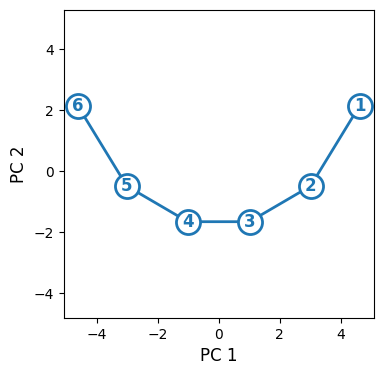

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def generate_data_adjusted(num_objects, num_dimensions, num_encoded_per_dim):
    data = np.zeros((num_objects, num_dimensions))
    for dim in range(num_dimensions):
        for rank in range(num_encoded_per_dim):
            obj = dim + 1 - rank 
            if 1 <= obj <= num_objects:
                data[obj - 1, dim] = obj - 3.5 
                
    return data

# Example usage
num_objects = 6

num_encoded_per_dim = 6 # Adjust the number of objects to encode per dimension
num_dimensions = num_objects+num_encoded_per_dim-1
# Generate the data
data = generate_data_adjusted(num_objects, num_dimensions, num_encoded_per_dim)
# data = data[:,1:-1]

# Perform PCA to reduce dimensions from 10 to 2
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

# Plot the PCA results in 2D
plt.figure(figsize=(4,4))
plot_data = np.zeros((2,len(data_pca)))
for i, (x, y) in enumerate(data_pca):
    plt.scatter(x, y, s=300, color='white', edgecolor='tab:blue', linewidths=2,zorder=1)  # Large white circles
    plt.text(x, y, f'{i + 1}', ha='center', va='center', fontsize=12, fontweight='bold', color='tab:blue', zorder=2)  # Bold object index
    plot_data[0,i]=x
    plot_data[1,i]=y
plt.plot(plot_data[0],plot_data[1],zorder=0,color='tab:blue', lw=2)
# Set titles and labels with consistent font size
# plt.title("2D Visualization of 12 Objects Using PCA", fontsize=12)
plt.xlabel("PC 1", fontsize=12)
plt.ylabel("PC 2", fontsize=12)
plt.axis('equal')
# plt.title()
plt.show()


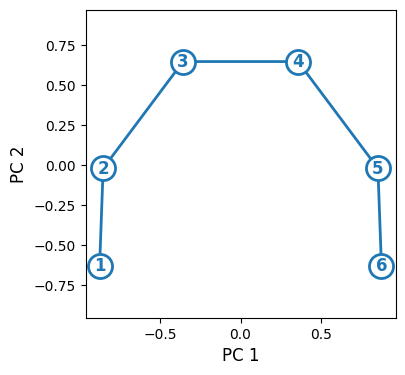

In [4]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def generate_data_gaussian(num_objects, num_dimensions, sigma=1.0, amplitude=1.0, center_mode="shifted"):
    """
    Build an (num_objects x num_dimensions) response matrix where each "dimension"
    corresponds to a rank-selective neuron with a Gaussian tuning curve over object rank.

    - num_objects: number of items/ranks (1..num_objects)
    - num_dimensions: number of neurons/dimensions
    - sigma: fixed std dev for all Gaussians (same variance)
    - amplitude: peak firing rate scaling
    - center_mode:
        * "shifted": centers sweep over a slightly wider range than [1, num_objects]
                     (useful if you previously had extra dims for edge effects)
        * "within": centers evenly spaced strictly within [1, num_objects]
    """
    ranks = np.arange(1, num_objects + 1)[:, None]  # shape (N, 1)

    if center_mode == "within":
        centers = np.linspace(1, num_objects, num_dimensions)
    elif center_mode == "shifted":
        # Spread centers across the wider range that arises when using extra dimensions
        # similar spirit to your previous construction with num_dimensions = N + K - 1.
        extra = (num_dimensions - num_objects) / 2.0
        centers = np.linspace(1 - extra, num_objects + extra, num_dimensions)
    else:
        raise ValueError("center_mode must be 'shifted' or 'within'")

    centers = centers[None, :]  # shape (1, M)

    # Gaussian tuning: exp(-(r - mu)^2 / (2*sigma^2))
    data = amplitude * np.exp(-0.5 * ((ranks - centers) / sigma) ** 2)

    # Optional: mean-center each neuron's activity across objects (often helps PCA look like manifolds)
    # data = data - data.mean(axis=0, keepdims=True)

    return data


# ----------------------------
# Example usage (your settings)
# ----------------------------
num_objects = 6
num_encoded_per_dim = 6
num_dimensions = num_objects + num_encoded_per_dim - 1

# Generate Gaussian-tuned data
sigma = 1.0          # fixed variance across neurons (variance = sigma^2)
amplitude = 1.0
data = generate_data_gaussian(
    num_objects=num_objects,
    num_dimensions=num_dimensions,
    sigma=sigma,
    amplitude=amplitude,
    center_mode="shifted"   # try "within" if you don't want extra edge centers
)

# PCA to 2D
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

# Plot
plt.figure(figsize=(4, 4))
plot_data = np.zeros((2, len(data_pca)))

for i, (x, y) in enumerate(data_pca):
    plt.scatter(x, y, s=300, color='white', edgecolor='tab:blue', linewidths=2, zorder=1)
    plt.text(x, y, f'{i + 1}', ha='center', va='center',
             fontsize=12, fontweight='bold', color='tab:blue', zorder=2)
    plot_data[0, i] = x
    plot_data[1, i] = y

plt.plot(plot_data[0], plot_data[1], zorder=0, color='tab:blue', lw=2)
plt.xlabel("PC 1", fontsize=12)
plt.ylabel("PC 2", fontsize=12)
plt.axis('equal')
plt.show()


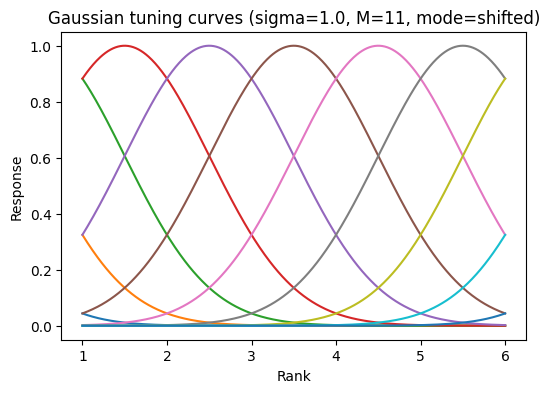

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def generate_data_gaussian(num_objects, num_dimensions, sigma=1.0, amplitude=1.0, center_mode="shifted"):
    ranks = np.arange(1, num_objects + 1)[:, None]  # (N,1)

    if center_mode == "within":
        centers = np.linspace(1, num_objects, num_dimensions)
    elif center_mode == "shifted":
        extra = (num_dimensions - num_objects) / 2.0
        centers = np.linspace(1 - extra, num_objects + extra, num_dimensions)
    else:
        raise ValueError("center_mode must be 'shifted' or 'within'")

    centers = centers[None, :]  # (1,M)
    data = amplitude * np.exp(-0.5 * ((ranks - centers) / sigma) ** 2)
    return data, centers.flatten()

# Settings (match your previous example)
num_objects = 6
num_encoded_per_dim = 6
num_dimensions = num_objects + num_encoded_per_dim - 1
sigma = 1.0
amplitude = 1.0
center_mode = "shifted"

# For a continuous-looking plot, sample ranks densely
ranks_dense = np.linspace(1, num_objects, 500)[:, None]  # (R,1)

# Create centers
if center_mode == "within":
    centers = np.linspace(1, num_objects, num_dimensions)
else:
    extra = (num_dimensions - num_objects) / 2.0
    centers = np.linspace(1 - extra, num_objects + extra, num_dimensions)

# Compute dense tuning curves
tuning_dense = amplitude * np.exp(-0.5 * ((ranks_dense - centers[None, :]) / sigma) ** 2)

# Plot all tuning curves
plt.figure(figsize=(6, 4))
for j in range(num_dimensions):
    plt.plot(ranks_dense[:, 0], tuning_dense[:, j])

plt.xlabel("Rank")
plt.ylabel("Response")
plt.title(f"Gaussian tuning curves (sigma={sigma}, M={num_dimensions}, mode={center_mode})")
plt.xticks(range(1, num_objects + 1))
plt.ylim(-0.05, 1.05)
plt.show()


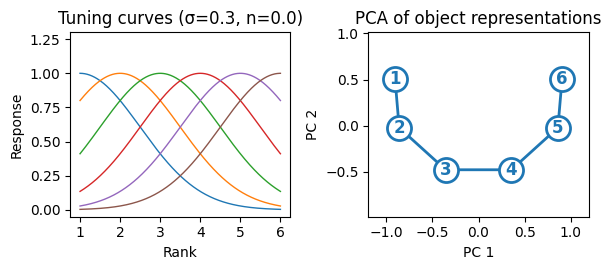

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def make_centers_fixed_neurons(num_objects, num_neurons, spacing_scale=1.0):
    """
    spacing_scale > 1 : sparser
    spacing_scale < 1 : denser
    """
    base = np.linspace(1, num_objects, num_neurons)
    center = base.mean()
    return center + spacing_scale * (base - center)

def gaussian_tuning(ranks, centers, sigma=1.0, amplitude=1.0):
    """
    ranks: (R,)
    centers: (M,)
    returns: (R, M)
    """
    ranks = ranks[:, None]
    centers = centers[None, :]
    return amplitude * np.exp(-0.5 * ((ranks - centers) / sigma) ** 2)


def add_noise(tuning, noise_scale=0.0, rng=None):
    """
    Add i.i.d. Gaussian noise to tuning curves.
    """
    if noise_scale <= 0:
        return tuning
    if rng is None:
        rng = np.random.default_rng(1)
    noisy = tuning + rng.normal(0.0, noise_scale, size=tuning.shape)
    return np.clip(noisy, 0.0, None)   # firing rates ≥ 0


def plot_tuning_and_pca(
    num_objects=6,
    num_neurons=11,
    sigma=1.0,
    amplitude=1.0,
    noise_scale=0.0,
    center_mode="shifted",
    dense_points=600,
    seed=0,
    connect_points=True,
    mean_center_neurons=False,
):
    rng = np.random.default_rng(seed)

    # neuron preferred ranks
    centers = make_centers_fixed_neurons(num_objects, num_neurons, spacing_scale=1.0)

    # ---------- Left: continuous tuning curves ----------
    ranks_dense = np.linspace(1, num_objects, dense_points)
    tuning_dense = gaussian_tuning(ranks_dense, centers, sigma, amplitude)
    tuning_dense = add_noise(tuning_dense, noise_scale, rng)

    # ---------- Right: PCA on object representations ----------
    ranks_discrete = np.arange(1, num_objects + 1)
    data = gaussian_tuning(ranks_discrete, centers, sigma, amplitude)
    data = add_noise(data, noise_scale, rng)

    if mean_center_neurons:
        data = data - data.mean(axis=0, keepdims=True)

    pca = PCA(n_components=2)
    data_pca = pca.fit_transform(data)

    # ---------- Plot ----------
    fig, axes = plt.subplots(1, 2, figsize=(6, 2.8))

    # Left panel
    ax = axes[0]
    for j in range(num_neurons):
        ax.plot(ranks_dense, tuning_dense[:, j], lw=1)
    ax.set_title(f"Tuning curves (σ={sigma_norm}, n={noise_scale})")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Response")
    ax.set_xticks(range(1, num_objects + 1))
    ax.set_ylim(-0.05 * amplitude, 1.3 * amplitude)

    # Right panel
    ax = axes[1]
    xs, ys = data_pca[:, 0], data_pca[:, 1]
    for i in range(num_objects):
        ax.scatter(xs[i], ys[i], s=300, facecolor="white",
                   edgecolor="tab:blue", linewidth=2, zorder=2)
        ax.text(xs[i], ys[i], f"{i+1}",
                ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="tab:blue", zorder=3)

    if connect_points:
        ax.plot(xs, ys, color="tab:blue", lw=2, zorder=1)

    ax.set_title("PCA of object representations")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.axis("equal")
    # Get current limits
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    # Enlarge by a fraction (e.g. 10%)
    pad = 0.1
    ax.set_xlim(x_min - pad * (x_max - x_min),
                x_max + pad * (x_max - x_min))
    ax.set_ylim(y_min - pad * (y_max - y_min),
                y_max + pad * (y_max - y_min))
    

    plt.tight_layout()
    plt.show()


# --------------------
# Example run
# --------------------
def sigma_from_norm(num_objects, sigma_norm, eps=1e-6):
    rank_range = max(num_objects - 1, 1)  # N-1 (avoid 0 when N=1)
    return max(sigma_norm * rank_range, eps)

num_objects= 6
sigma_norm = 0.3                # in (0,1], fraction of full rank range
sigma = sigma_from_norm(num_objects, sigma_norm)

plot_tuning_and_pca(
    num_objects=num_objects,
    num_neurons=6,     # <-- explicit, meaningful parameter
    sigma=sigma,
    noise_scale=0.0,
    center_mode="shifted",
    mean_center_neurons=False,
    seed=0
)


In [41]:
1/6*0.33

0.055